<a href="https://colab.research.google.com/github/mim-1999/ames-housing-regression/blob/main/Ames_Housing_EDA_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Create the 'images' directory if it doesn't exist
os.makedirs('images', exist_ok=True)

## Load dataset and understand it

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Ames_Housing_Project/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.shape

(1460, 81)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## check missing values

In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [ ]:
cols_with_missing = missing.index.tolist()
print(df.loc[df[cols_with_missing].isnull().any(axis=1), cols_with_missing].to_string())

     PoolQC MiscFeature Alley  Fence MasVnrType FireplaceQu  LotFrontage GarageType  GarageYrBlt GarageFinish GarageQual GarageCond BsmtExposure BsmtFinType2 BsmtQual BsmtCond BsmtFinType1  MasVnrArea Electrical
0       NaN         NaN   NaN    NaN    BrkFace         NaN         65.0     Attchd       2003.0          RFn         TA         TA           No          Unf       Gd       TA          GLQ       196.0      SBrkr
1       NaN         NaN   NaN    NaN        NaN          TA         80.0     Attchd       1976.0          RFn         TA         TA           Gd          Unf       Gd       TA          ALQ         0.0      SBrkr
2       NaN         NaN   NaN    NaN    BrkFace          TA         68.0     Attchd       2001.0          RFn         TA         TA           Mn          Unf       Gd       TA          GLQ       162.0      SBrkr
3       NaN         NaN   NaN    NaN        NaN          Gd         60.0     Detchd       1998.0          Unf         TA         TA           No        

In [ ]:
basement_cols = ['BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
#df[df[basement_cols].isnull().any(axis=1)][basement_cols]
df.loc[df[basement_cols].isnull().any(axis=1),basement_cols]

,BsmtExposure,BsmtFinType2,BsmtQual,BsmtCond,BsmtFinType1
17,NaN,NaN,NaN,NaN,NaN
39,NaN,NaN,NaN,NaN,NaN
90,NaN,NaN,NaN,NaN,NaN
102,NaN,NaN,NaN,NaN,NaN
156,NaN,NaN,NaN,NaN,NaN
182,NaN,NaN,NaN,NaN,NaN
259,NaN,NaN,NaN,NaN,NaN
332,No,NaN,Gd,TA,GLQ
342,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN


## Handle missing values


In [ ]:
basement_cols = ['BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for col in basement_cols:
    df[col] = df[col].fillna('None')

In [ ]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')

In [ ]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [ ]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [ ]:
df.isnull().sum().sum()

np.int64(0)

## EDA

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


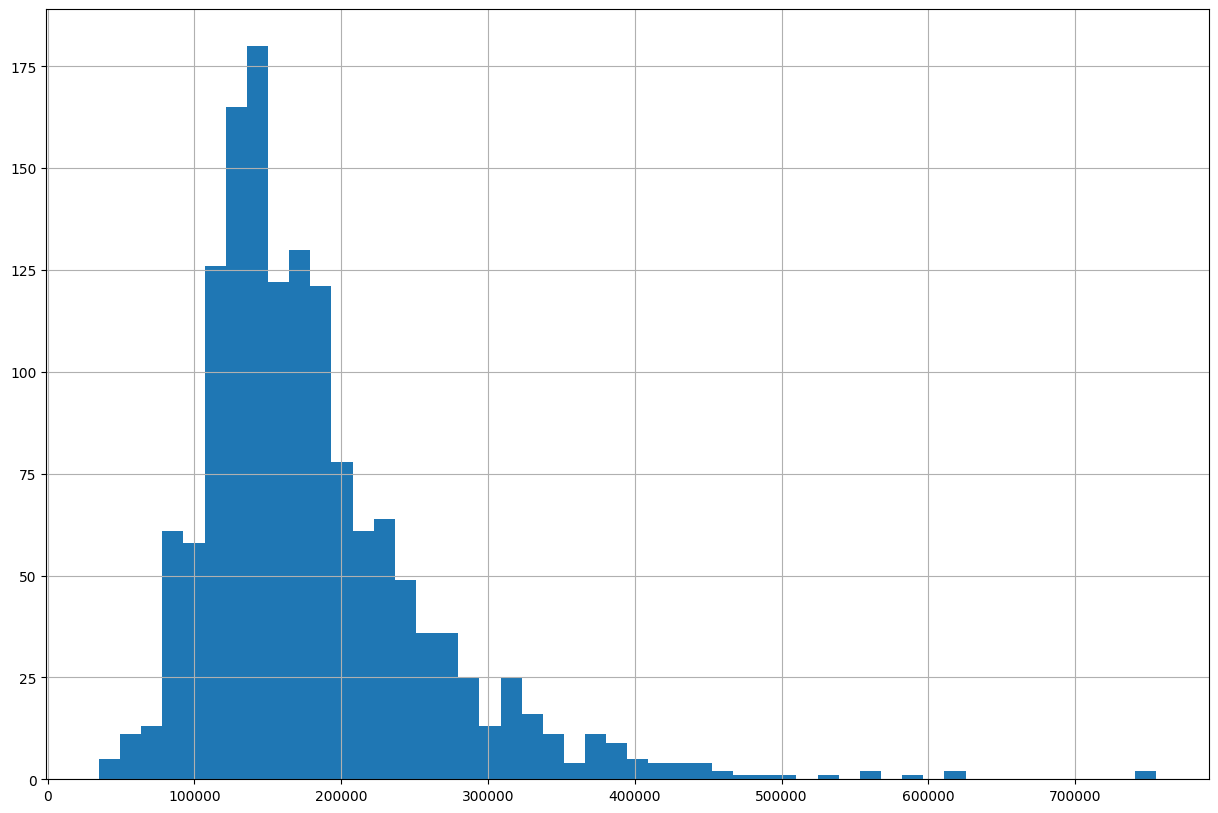

In [ ]:
# target variable's distribution
df['SalePrice'].hist(bins=50, figsize=(15,10))
plt.savefig('images/hist_saleprice.png', dpi=100)
plt.show()

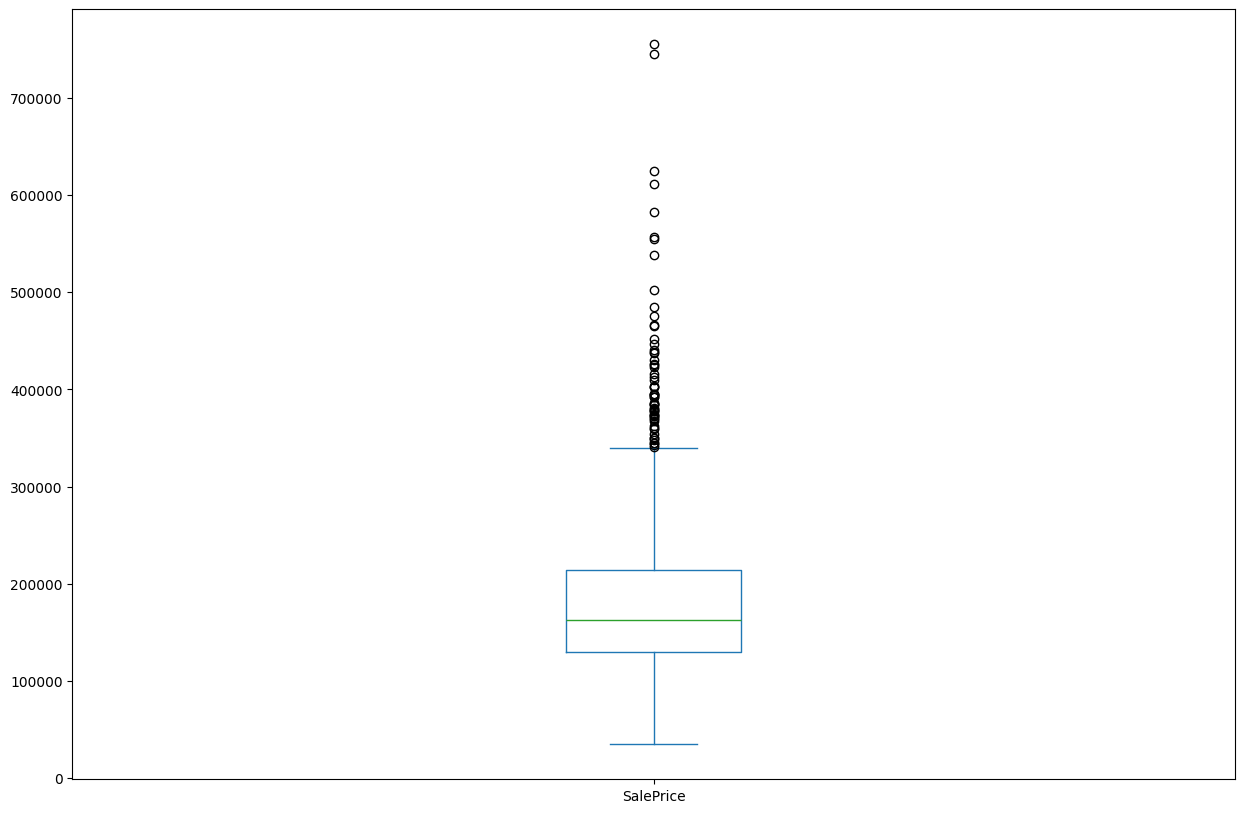

In [ ]:
df['SalePrice'].plot(kind='box', figsize=(15,10), sharex=False)
plt.savefig('images/box_saleprice.png', dpi=100)
plt.show()

## Bivariate analysis + Univariate Analysis

### Analyze numeric features and their price correlations

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(correlations)
# GarageCars and GarageArea are basically measuring the same thing; Same pattern with TotalBsmtSF and 1stFlrSF


SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

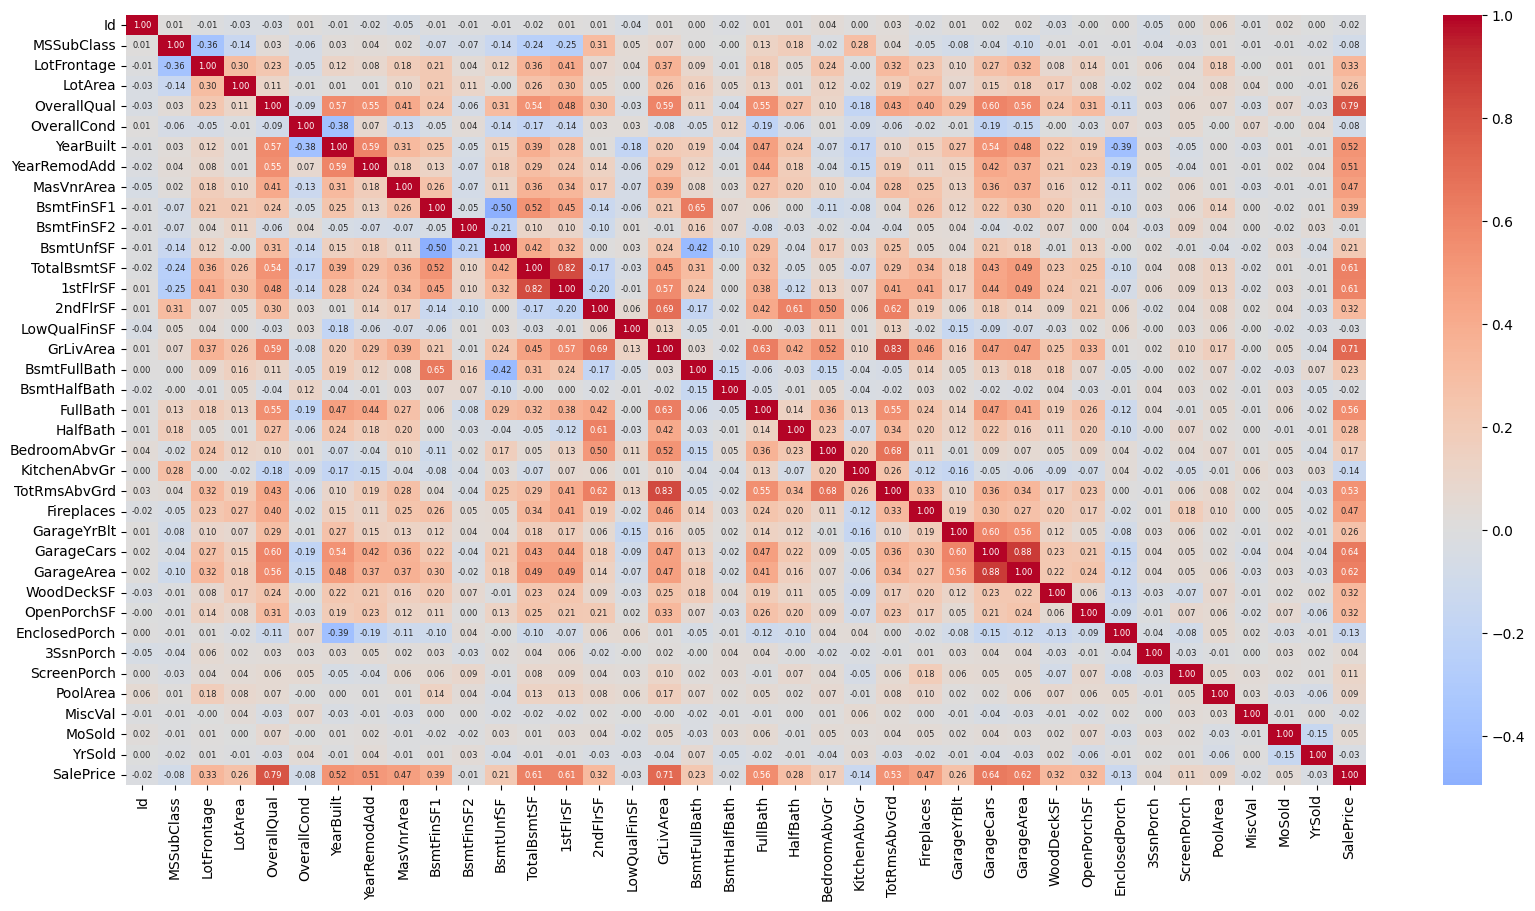

In [ ]:
# Visualize the full correlation matrix as a heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0, annot_kws={'size': 6})
plt.savefig('images/heatmap_correlations.png', dpi=100)
plt.show()

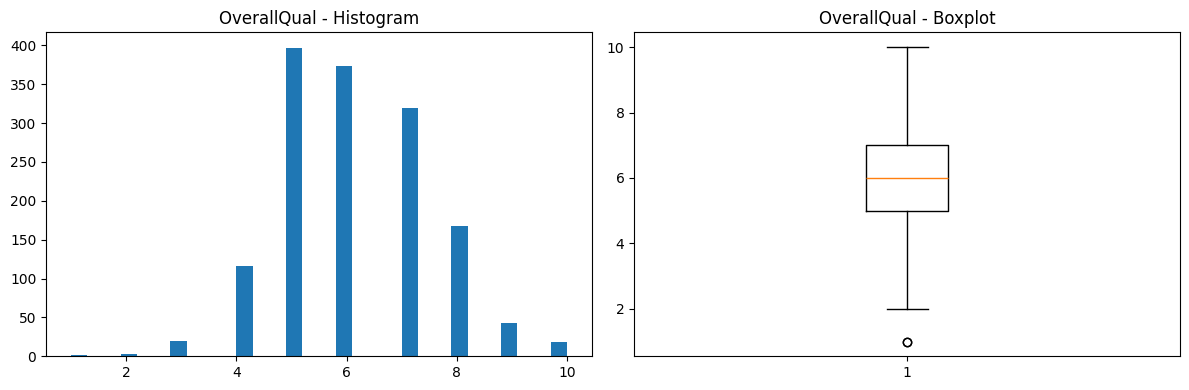

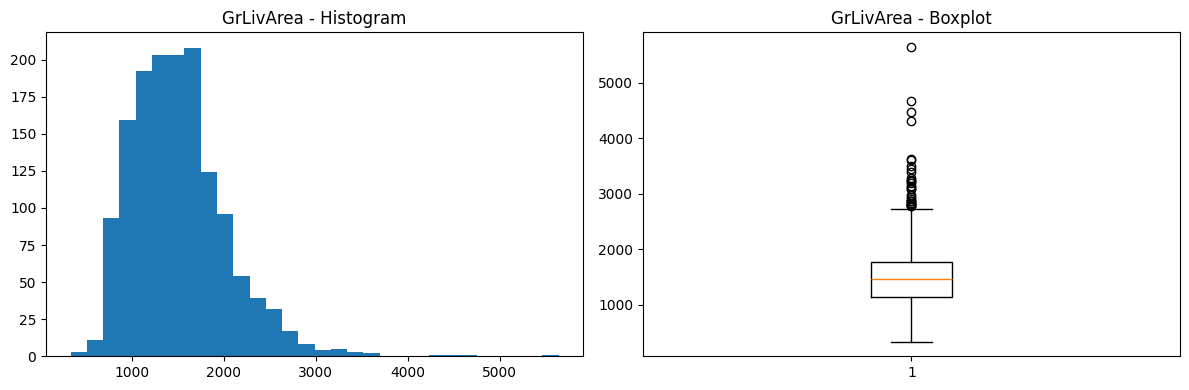

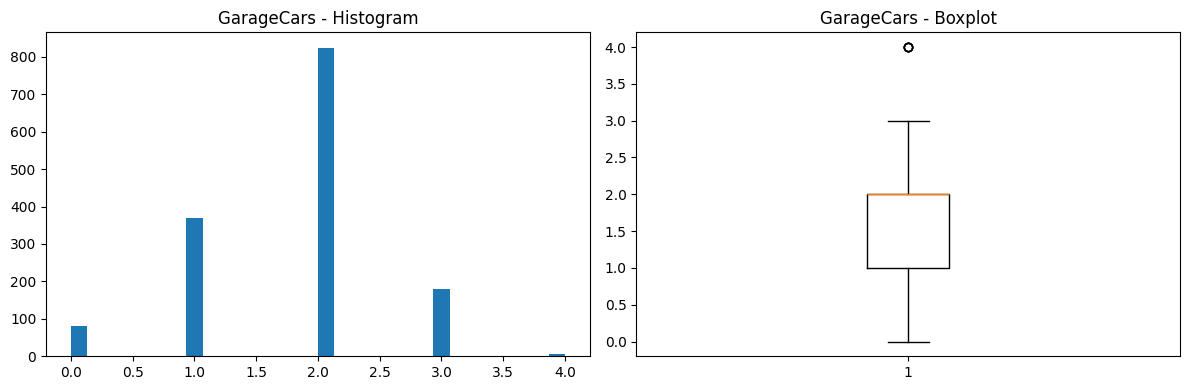

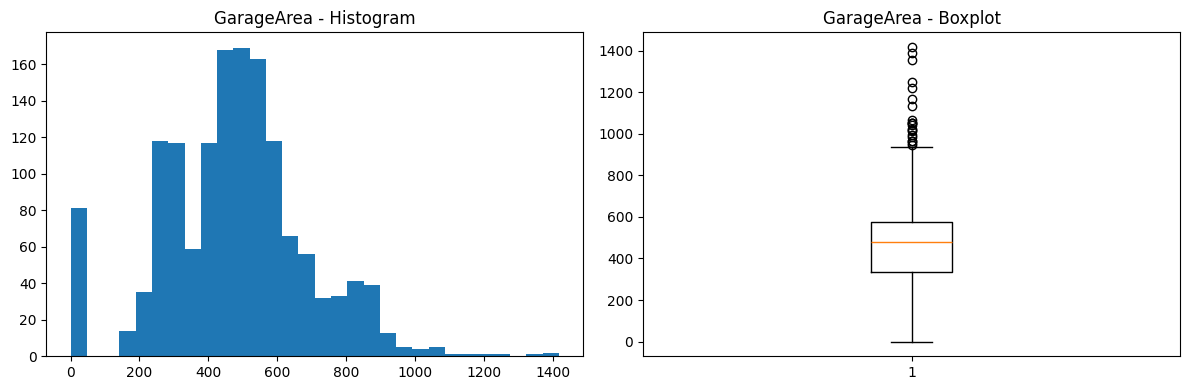

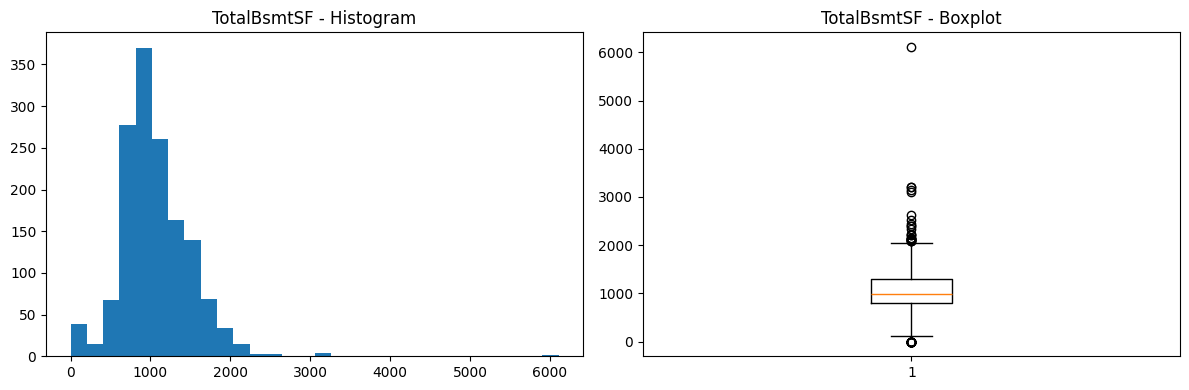

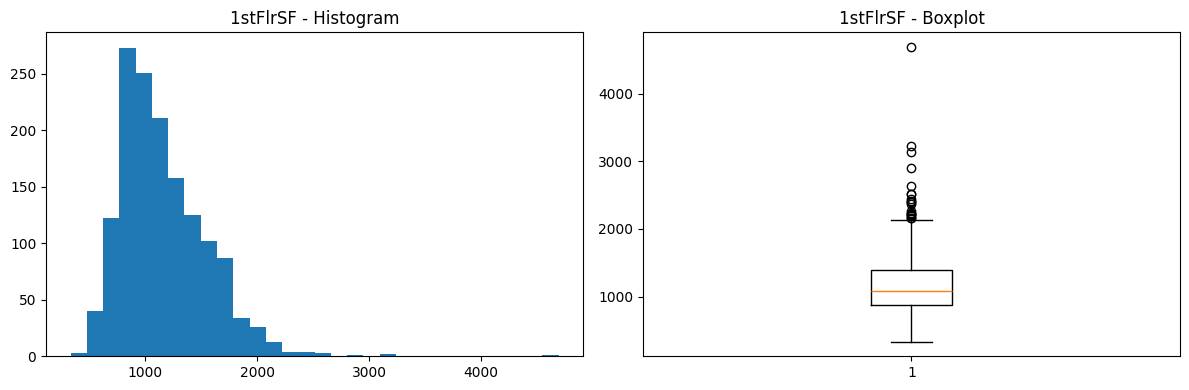

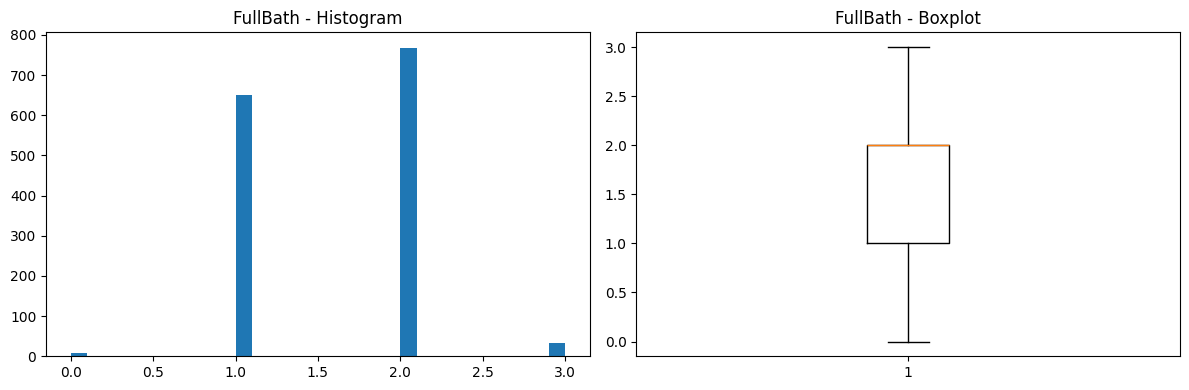

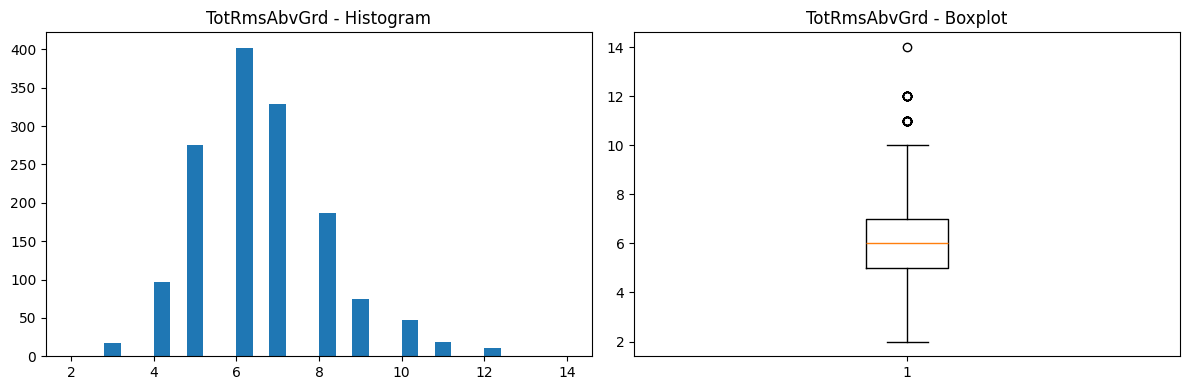

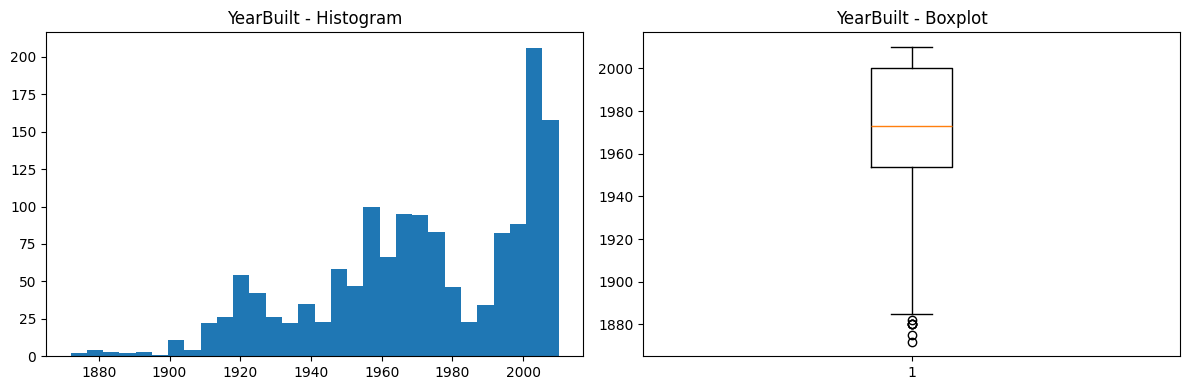

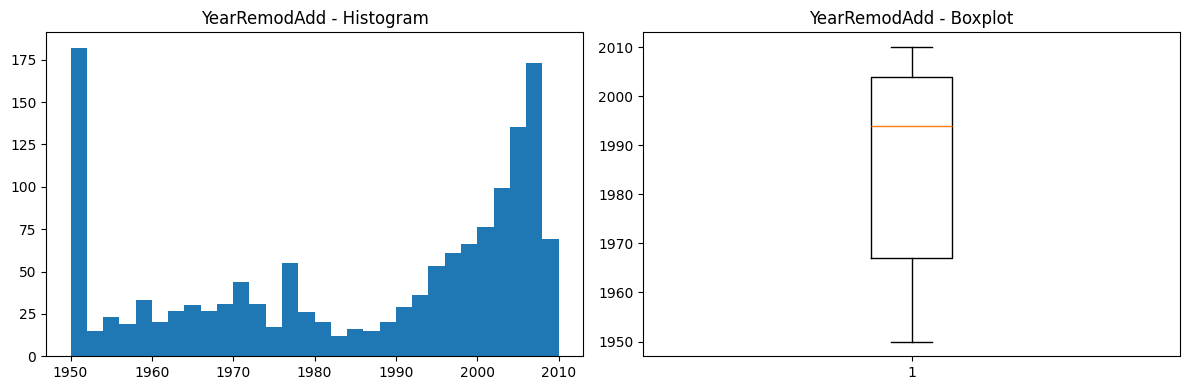

In [ ]:
# numeric features histograms and boxplots

top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
                 'YearBuilt', 'YearRemodAdd']

for feature in top_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[feature], bins=30)
    axes[0].set_title(f'{feature} - Histogram')

    axes[1].boxplot(df[feature])
    axes[1].set_title(f'{feature} - Boxplot')

    plt.tight_layout()
    plt.savefig('images/histograms&boxplots_top_numeric_features.png', dpi=100)
    plt.show()

# house was never remodeled, YearRemodAdd is simply set equal to YearBuilt (the original construction year)

### Analyze categorical features and their price correlations

In [ ]:
# ranks every categorical column by how much it separates cheap vs. expensive houses
categorical_cols = df.select_dtypes(include=['object']).columns

price_range_by_category = {}
for col in categorical_cols:
  group_means = df.groupby(col)['SalePrice'].mean()
  price_range_by_category[col] = group_means.max() - group_means.min()

price_range_series = pd.Series(price_range_by_category).sort_values(ascending=False)
print(price_range_series)

# Big price gap + tiny sample = coincidence, not signal


PoolQC           309595.336545
ExterQual        279375.747253
RoofMatl         253250.000000
Neighborhood     236718.846485
Condition2       228250.000000
KitchenQual      222989.464872
BsmtQual         221388.149430
Exterior2nd      214000.000000
FireplaceQu      207948.350000
Exterior1st      191000.000000
SaleCondition    168166.752000
MiscFeature      156000.000000
SaleType         155095.418033
GarageType       151434.454686
BsmtExposure     149751.463865
BsmtCond         149599.907692
GarageQual       140833.333333
MSZoning         139486.061538
GarageFinish     136735.406390
BsmtFinType1     129760.828204
HeatingQC        127914.429150
ExterCond        124833.333333
Electrical       119810.637453
MasVnrType       119265.558333
Foundation       117864.817040
HouseStyle       109850.000000
Heating          109521.195378
BsmtFinType2      99595.868421
Functional        97629.147059
Condition1        90783.333333
LandContour       88429.860635
GarageCond        84568.451344
CentralA

In [ ]:
# which categorical features high ranking is trustworthy
print(df.groupby('Utilities')['SalePrice'].agg(['mean', 'count']))
print(df.groupby('PoolQC')['SalePrice'].agg(['mean', 'count']))
print(df.groupby('ExterQual')['SalePrice'].agg(['mean', 'count']))
print(df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'count']))
print(df.groupby('KitchenQual')['SalePrice'].agg(['mean', 'count']))
print(df.groupby('BsmtQual')['SalePrice'].agg(['mean', 'count']))
# Big price gap + hundreds of houses = real pattern.

                   mean  count
Utilities                     
AllPub     180950.95682   1459
NoSeWa     137500.00000      1
                 mean  count
PoolQC                      
Ex      490000.000000      2
Fa      215500.000000      2
Gd      201990.000000      3
None    180404.663455   1453
                    mean  count
ExterQual                      
Ex         367360.961538     52
Fa          87985.214286     14
Gd         231633.510246    488
TA         144341.313466    906
                       mean  count
Neighborhood                      
Blmngtn       194870.882353     17
Blueste       137500.000000      2
BrDale        104493.750000     16
BrkSide       124834.051724     58
ClearCr       212565.428571     28
CollgCr       197965.773333    150
Crawfor       210624.725490     51
Edwards       128219.700000    100
Gilbert       192854.506329     79
IDOTRR        100123.783784     37
MeadowV        98576.470588     17
Mitchel       156270.122449     49
NAmes         145847

In [ ]:
print("Selected Categorical Features are:'ExterQual', 'KitchenQual', 'BsmtQual', 'Neighborhood' ")

Selected Categorical Features are:'ExterQual', 'KitchenQual', 'BsmtQual', 'Neighborhood' 


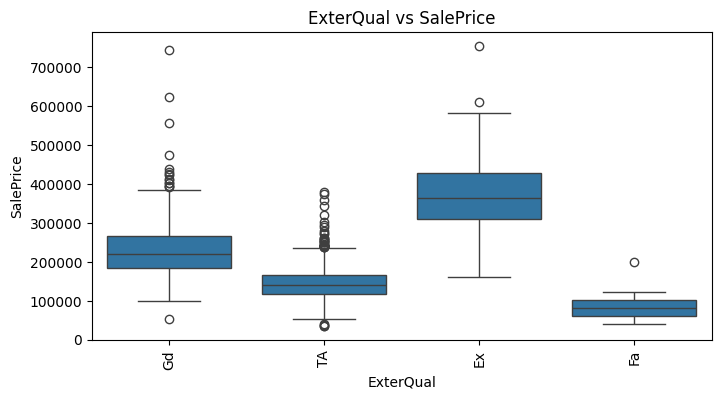

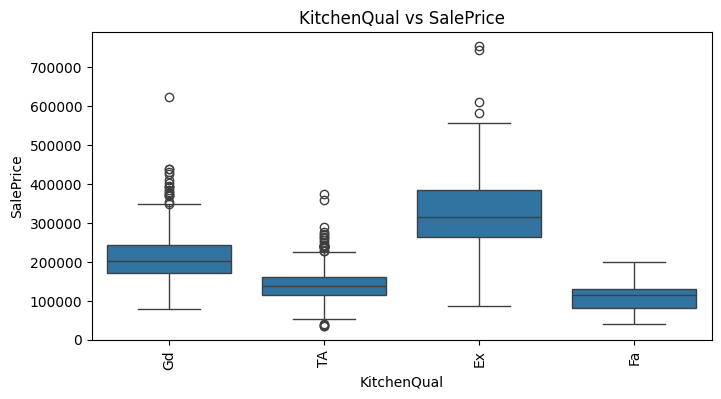

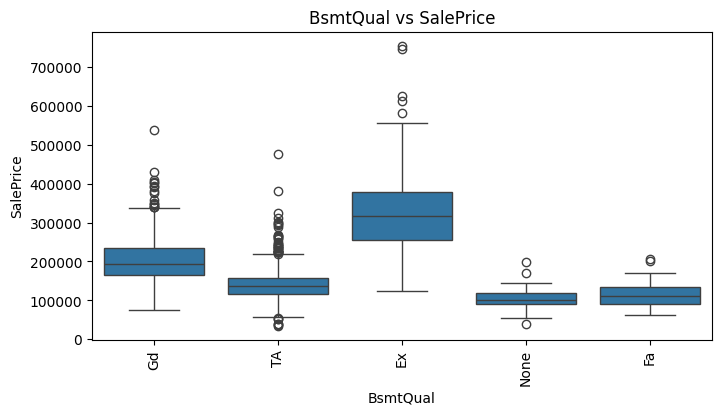

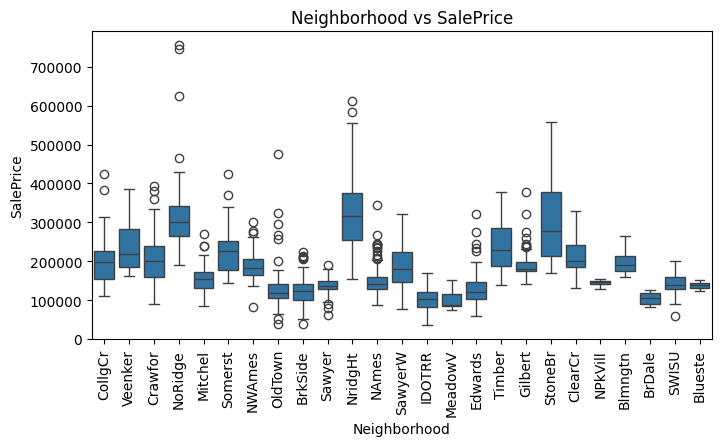

In [ ]:
# box plot for bivariate analysis for categorical features
categorical_features = ['ExterQual', 'KitchenQual', 'BsmtQual', 'Neighborhood']

for feature in categorical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=feature, y='SalePrice', data=df)
    plt.xticks(rotation=90)
    plt.title(f'{feature} vs SalePrice')
    plt.show()

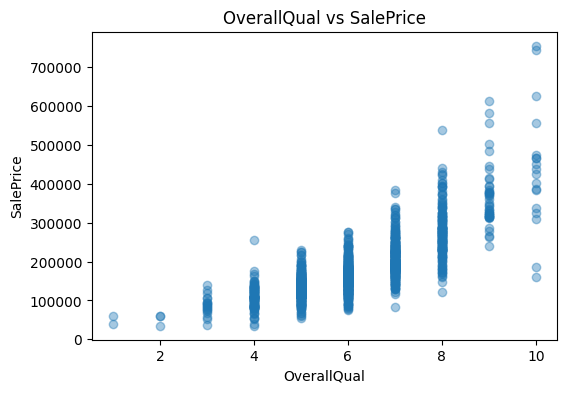

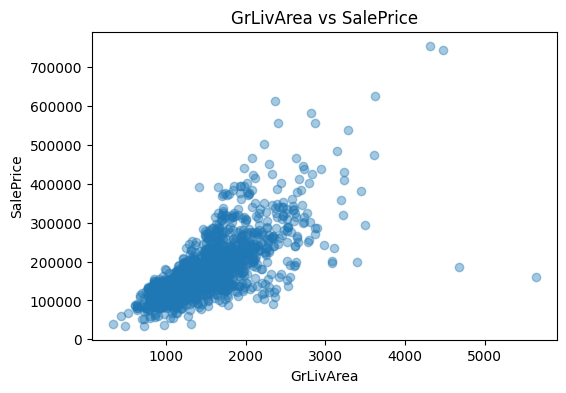

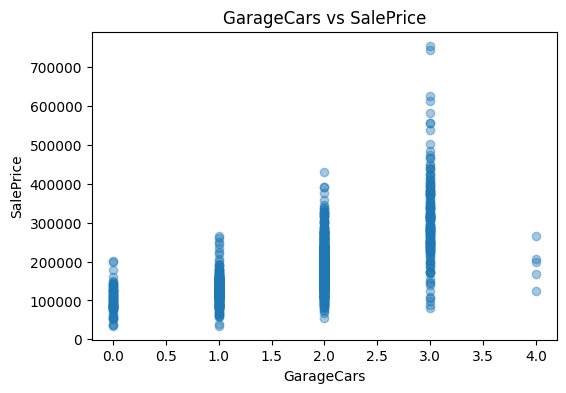

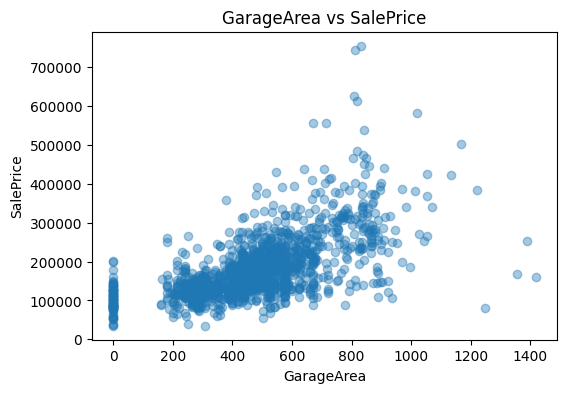

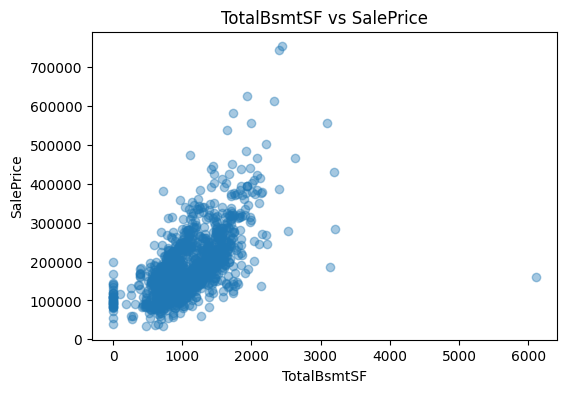

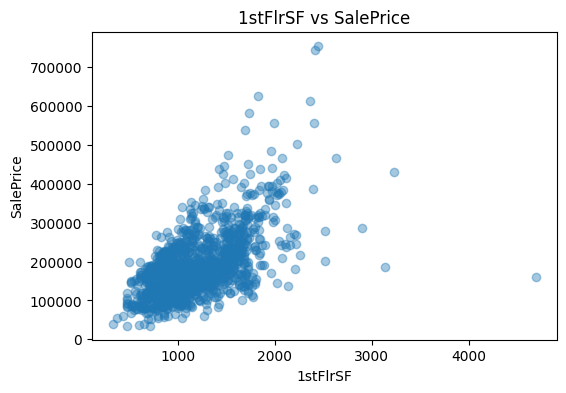

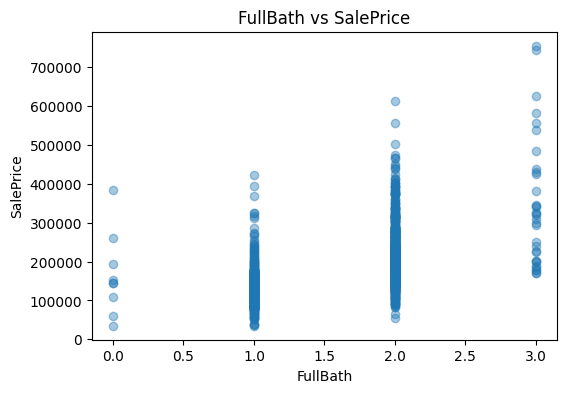

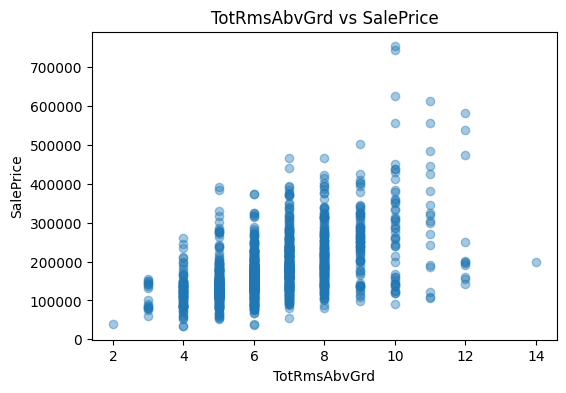

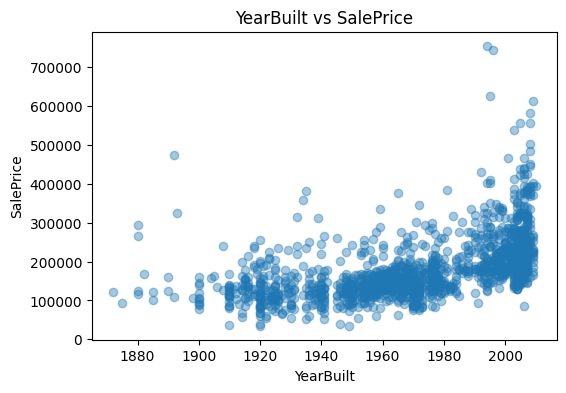

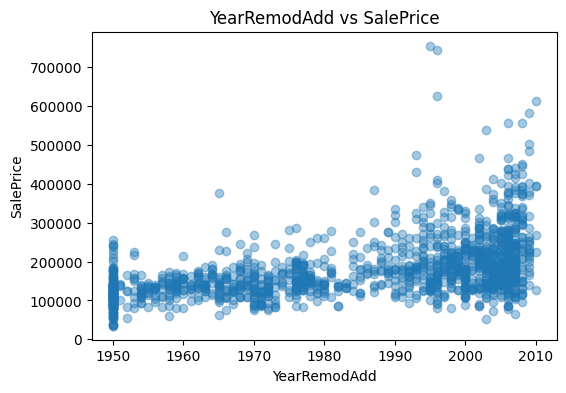

In [ ]:
# scatter plot for bivariate analysis for numeric features
top_numeric = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']

for feature in top_numeric:
    plt.figure(figsize=(6,4))
    plt.scatter(df[feature], df['SalePrice'], alpha=0.4)
    plt.xlabel(feature)
    plt.ylabel('SalePrice')
    plt.title(f'{feature} vs SalePrice')
    plt.show()

# bivariate outlier/anomaly: two variables that don't follow the expected relationship. data anomalies is present in the dataset; check multicolinearity flag

## Data Cleaning and Preprocessing

In [ ]:
df[(df['GrLivArea'] > 4000)][['GrLivArea', '1stFlrSF', 'TotalBsmtSF', 'TotRmsAbvGrd', 'SalePrice']]
# row 523 and 1298 that break the pattern (big house, surprisingly cheap)

,GrLivArea,1stFlrSF,TotalBsmtSF,TotRmsAbvGrd,SalePrice
523,4676,3138,3138,11,184750
691,4316,2444,2444,10,755000
1182,4476,2411,2396,10,745000
1298,5642,4692,6110,12,160000


In [ ]:
# remove anomilies - removal rule
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]

In [ ]:
df.shape

(1458, 81)

<Axes: >

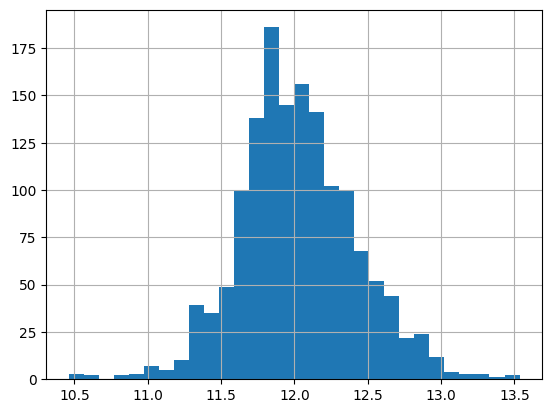

In [ ]:
## Log Transformation of SalePrice (to reduce right skew)
df['SalePrice_log'] = np.log(df['SalePrice'])
df['SalePrice_log'].hist(bins=30)

### #categorical encoding strategy for data preprocessing---(Hot Encoding)

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [ ]:
# hot encoding; drop first category so that 1st categoryof feature is discarded to avoid redundancy
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
print(df.shape)
print(df_encoded.shape)

(1458, 82)
(1458, 261)


In [ ]:
X = df_encoded.drop(columns=['SalePrice_log','SalePrice'])
y = df_encoded['SalePrice_log']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1166, 259) (292, 259) (1166,) (292,)


In [ ]:
# check VIF on traing data
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

numeric_features = X_train.select_dtypes(include=['int64', 'float64'])

vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_features.columns
vif_data['VIF'] = [variance_inflation_factor(numeric_features.values, i)
                    for i in range(numeric_features.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

          Feature           VIF
16      GrLivArea           inf
9      BsmtFinSF1           inf
10     BsmtFinSF2           inf
11      BsmtUnfSF           inf
12    TotalBsmtSF           inf
14       2ndFlrSF           inf
15   LowQualFinSF           inf
13       1stFlrSF           inf
36         YrSold  2.186436e+04
7    YearRemodAdd  2.143784e+04
6       YearBuilt  1.712617e+04
23   TotRmsAbvGrd  8.510223e+01
4     OverallQual  6.569076e+01
26     GarageCars  4.222672e+01
5     OverallCond  4.193737e+01
22   KitchenAbvGr  3.899026e+01
21   BedroomAbvGr  3.310231e+01
25    GarageYrBlt  3.227917e+01
27     GarageArea  3.145533e+01
19       FullBath  2.604411e+01
2     LotFrontage  1.781927e+01
35         MoSold  6.717028e+00
1      MSSubClass  4.747297e+00
0              Id  4.095015e+00
17   BsmtFullBath  3.807856e+00
20       HalfBath  3.303687e+00
24     Fireplaces  2.978341e+00
3         LotArea  2.450639e+00
8      MasVnrArea  1.961288e+00
28     WoodDeckSF  1.936462e+00
29    Op

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
# keep the aggregate totals to drop redundant due to high correlations with sale
drop_redundant = ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']
X_train = X_train.drop(columns=drop_redundant)
X_test = X_test.drop(columns=drop_redundant)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

numeric_features = X_train.select_dtypes(include=['int64', 'float64'])

vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_features.columns
vif_data['VIF'] = [variance_inflation_factor(numeric_features.values, i)
                    for i in range(numeric_features.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)
#years have limitation like high VIF due to big number

          Feature           VIF
30         YrSold  21544.532019
7    YearRemodAdd  21076.183839
6       YearBuilt  16848.335804
17   TotRmsAbvGrd     84.809849
10      GrLivArea     65.177713
4     OverallQual     64.803929
20     GarageCars     42.096273
5     OverallCond     41.564424
16   KitchenAbvGr     36.363111
15   BedroomAbvGr     32.044357
19    GarageYrBlt     31.849304
21     GarageArea     31.329843
13       FullBath     25.659265
2     LotFrontage     17.759716
9     TotalBsmtSF     16.816029
29         MoSold      6.704463
1      MSSubClass      4.491519
0              Id      4.056060
18     Fireplaces      2.861855
14       HalfBath      2.747534
3         LotArea      2.439929
11   BsmtFullBath      2.182368
22     WoodDeckSF      1.925393
8      MasVnrArea      1.922651
23    OpenPorchSF      1.795776
24  EnclosedPorch      1.437390
26    ScreenPorch      1.222793
12   BsmtHalfBath      1.177957
27       PoolArea      1.082490
25      3SsnPorch      1.048316
28      

### Feature Engineering: House Age & Years Since Remodel

In [ ]:
# feature engineering — creating a new, more useful feature out of existing ones, rather than just cleaning or dropping
X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']
X_train['YearsSinceRemod'] = X_train['YrSold'] - X_train['YearRemodAdd']
X_train = X_train.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd'])

X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']
X_test['YearsSinceRemod'] = X_test['YrSold'] - X_test['YearRemodAdd']
X_test = X_test.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd'])

In [ ]:
print(X_train[['HouseAge', 'YearsSinceRemod']].describe())

          HouseAge  YearsSinceRemod
count  1166.000000      1166.000000
mean     36.899657        23.028302
std      30.266531        20.601931
min       0.000000         0.000000
25%       8.000000         4.000000
50%      36.000000        14.000000
75%      55.000000        41.000000
max     136.000000        60.000000


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

numeric_features = X_train.select_dtypes(include=['int64', 'float64'])

vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_features.columns
vif_data['VIF'] = [variance_inflation_factor(numeric_features.values, i)
                    for i in range(numeric_features.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

            Feature        VIF
15     TotRmsAbvGrd  84.330902
8         GrLivArea  61.632679
4       OverallQual  52.705205
18       GarageCars  41.990948
5       OverallCond  34.429887
13     BedroomAbvGr  31.871080
19       GarageArea  31.268433
14     KitchenAbvGr  31.122208
17      GarageYrBlt  28.926742
11         FullBath  25.015920
2       LotFrontage  16.964349
7       TotalBsmtSF  16.315152
28         HouseAge   9.799335
27           MoSold   6.578517
29  YearsSinceRemod   4.672191
1        MSSubClass   4.446118
0                Id   3.981330
16       Fireplaces   2.842780
12         HalfBath   2.683241
3           LotArea   2.439548
9      BsmtFullBath   2.161341
20       WoodDeckSF   1.922421
6        MasVnrArea   1.907256
21      OpenPorchSF   1.795677
22    EnclosedPorch   1.437321
24      ScreenPorch   1.219154
10     BsmtHalfBath   1.177773
25         PoolArea   1.082003
23        3SsnPorch   1.048302
26          MiscVal   1.035032
